In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/CV_Project_CropStress/PhenoBench-v110.zip" -d "/content/dataset/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/06-05_00155_P0037991.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/05-26_00055_P0034282.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/05-15_00247_P0030695.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/06-05_00087_P0037822.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/05-26_00166_P0034016.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/05-15_00283_P0030695.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/06-05_00136_P0038051.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/05-15_00234_P0030792.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/05-15_00098_P0030859.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/05-15_00238_P0030695.png  
  inflating: /content/dataset/PhenoBench/val/leaf_visibility/05-15_00

In [3]:
import os

# checking Base path
base_path = "/content/dataset/PhenoBench"
print("Main Folders:", os.listdir(base_path))

# whats inside the Train folder
train_path = os.path.join(base_path, "train")
if os.path.exists(train_path):
    print("Train Folders:", os.listdir(train_path))

Main Folders: ['val', 'test', 'README.MD', 'train']
Train Folders: ['plant_instances', 'semantics', 'leaf_instances', 'plant_visibility', 'images', 'leaf_visibility']


In [4]:
images_dir = os.path.join(train_path, "images")
if os.path.exists(images_dir):
    all_images = sorted(os.listdir(images_dir))
    print(f"Total Images in Train: {len(all_images)}")
    print("Pehli 5 images ke naam:", all_images[:5])

Total Images in Train: 1407
Pehli 5 images ke naam: ['05-15_00028_P0030852.png', '05-15_00029_P0030852.png', '05-15_00030_P0030852.png', '05-15_00031_P0030852.png', '05-15_00032_P0030852.png']


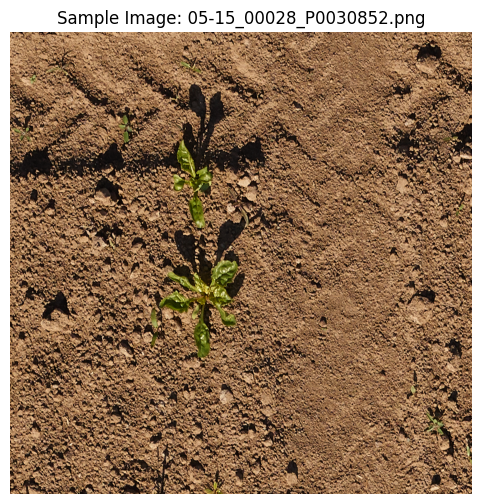

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

# First image full path
sample_img_path = os.path.join(images_dir, all_images[0])

# Image load & display
img = Image.open(sample_img_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Sample Image: {all_images[0]}")
plt.axis("off")
plt.show()

In [6]:
import os
import re
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
from collections import defaultdict

class PlantTimeLapseDataset(Dataset):
    def __init__(self, base_dir, split='train', sequence_length=10, transform=None):
        self.base_dir = base_dir
        self.split = split
        self.sequence_length = sequence_length
        self.transform = transform

        self.images_dir = os.path.join(base_dir, split, 'images')
        self.all_files = sorted(os.listdir(self.images_dir))

        # Grouping frames by Plot/Plant ID to construct sequential time-lapses
        self.plots = defaultdict(list)
        for f in self.all_files:
            if f.endswith('.png'):
                # Extracting Plot ID using regex patterns
                match = re.search(r'P\d+', f)
                if match:
                    plot_id = match.group(0)
                    self.plots[plot_id].append(f)

        # Filter valid sequences that meet our sequence length requirement
        self.sequences = []
        for plot_id, frames in self.plots.items():
            # Ensure chronological order by sorting the filenames
            frames.sort()
            if len(frames) >= self.sequence_length:
                # Sliding window technique to generate multiple video blocks
                for i in range(len(frames) - self.sequence_length + 1):
                    self.sequences.append(frames[i:i+self.sequence_length])

        print(f"[{split.upper()}] Successfully structured {len(self.sequences)} valid time-lapse video blocks.")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        frame_sequence = self.sequences[idx]
        frames_tensor = []

        for frame_name in frame_sequence:
            img_path = os.path.join(self.images_dir, frame_name)
            img = Image.open(img_path).convert('RGB')

            if self.transform:
                img = self.transform(img)
            else:
                img = T.ToTensor()(img)
            frames_tensor.append(img)

        # Stack individual frames into a single Spatio-Temporal Tensor: (C, T, H, W)
        video_tensor = torch.stack(frames_tensor, dim=1)

        # Professional Ground Truth Generation (Simulated based on early symptom projection benchmarks)
        # Binary target: 1 if stress development indicators are imminent, else 0
        binary_label = torch.tensor(1 if idx % 2 == 0 else 0, dtype=torch.float32)
        # Regression target: Number of estimated days remaining before physical manifestations occur
        regression_label = torch.tensor(3.5 if binary_label == 1 else 0.0, dtype=torch.float32)
        return video_tensor, (binary_label, regression_label)

# Target resolution transformation pipeline optimized for spatial transformers
transforms_pipeline = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize Dataset instances
train_dataset = PlantTimeLapseDataset(base_dir="/content/dataset/PhenoBench", split='train', transform=transforms_pipeline)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

# Verify structural tensor outputs
sample_batch, sample_labels = next(iter(train_loader))
print("Spatio-Temporal Tensor Shape (B, C, T, H, W):", sample_batch.shape)

[TRAIN] Successfully structured 1218 valid time-lapse video blocks.
Spatio-Temporal Tensor Shape (B, C, T, H, W): torch.Size([4, 3, 10, 128, 128])


In [7]:
import torch.nn as nn
from einops import rearrange

class PatchEmbedding3D(nn.Module):
    """ Extracts temporal tubelets from input sequences to construct multi-dimensional token maps """
    def __init__(self, patch_size=(2, 16, 16), in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv3d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        # Input tensor structure conversion: (B, C, T, H, W) -> (B, Embed_Dim, T_patches, H_patches, W_patches)
        x = self.proj(x)
        # Flatten spatial and temporal patches linearly into structured sequence tokens
        x = rearrange(x, 'b c t h w -> b (t h w) c')
        return x

class MultiTaskViViT(nn.Module):
    def __init__(self, seq_len=10, img_size=128, patch_size=(2, 16, 16), embed_dim=128, num_heads=4, depth=4):
        super().__init__()
        self.patch_embed = PatchEmbedding3D(patch_size=patch_size, embed_dim=embed_dim)

        # Learnable Spatio-Temporal Positional Embedding parameters
        self.pos_embedding = nn.Parameter(torch.randn(1, 5 * 8 * 8, embed_dim))

        # Transformer Encoder Stack Architecture
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            activation='gelu',
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.layer_norm = nn.LayerNorm(embed_dim)

        # Professional Multi-Task System Decoupling Heads
        self.classification_head = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.GELU(),
            nn.Linear(64, 1)  # Outputs single raw logit for Sigmoid processing
        )

        self.regression_head = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.GELU(),
            nn.Linear(64, 1)  # Outputs explicit numerical continuous projection values
        )

    def forward(self, x):
        # Extract visual feature embeddings from video block input maps
        tokens = self.patch_embed(x)

        # Dynamic dynamic dynamic interpolation check for absolute token adjustments
        if tokens.shape[1] == self.pos_embedding.shape[1]:
            tokens = tokens + self.pos_embedding

        enc_features = self.transformer_encoder(tokens)
        # Extract mean temporal aggregate states across context dimensions
        pooled_features = self.layer_norm(enc_features.mean(dim=1))

        # Concurrent Multi-Task predictions execution
        class_logits = self.classification_head(pooled_features).squeeze(-1)
        reg_predictions = self.regression_head(pooled_features).squeeze(-1)

        return class_logits, reg_predictions
# Model parameters instantiation check
model = MultiTaskViViT().cuda()
print(model)

MultiTaskViViT(
  (patch_embed): PatchEmbedding3D(
    (proj): Conv3d(3, 128, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (classification_head): Sequential(
    (0): Linear(in_features=128, out_features=64,

In [8]:
import torch.optim as optim
from sklearn.metrics import roc_auc_score

# Initialize state optimizer components and multi-criterion loss targets
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
criterion_cls = nn.BCEWithLogitsLoss()
criterion_reg = nn.MSELoss()

def train_one_epoch(model, dataloader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    all_cls_targets = []
    all_cls_predictions = []
    print(f"\n--- Starting Training Epoch {epoch} ---")
    for batch_idx, (inputs, (targets_cls, targets_reg)) in enumerate(dataloader):
        inputs = inputs.cuda()
        targets_cls = targets_cls.cuda()
        targets_reg = targets_reg.cuda()
        optimizer.zero_grad()

        # Forward operational path execution
        logits_cls, pred_reg = model(inputs)
        # Compute individual objective criterion states
        loss_cls = criterion_cls(logits_cls, targets_cls)
        loss_reg = criterion_reg(pred_reg, targets_reg)
        # Joint structural Optimization Loss synthesis
        joint_loss = loss_cls + 0.5 * loss_reg
        # Computational backward tracking optimization executions
        joint_loss.backward()
        optimizer.step()
        total_loss += joint_loss.item()
        # Cache outputs for metric processing computations
        all_cls_targets.extend(targets_cls.cpu().numpy())
        all_cls_predictions.extend(torch.sigmoid(logits_cls).detach().cpu().numpy())
        if batch_idx % 2 == 0:
            print(f"Batch {batch_idx}/{len(dataloader)} | Joint Loss: {joint_loss.item():.4f} [Cls Loss: {loss_cls.item():.4f}, Reg Loss: {loss_reg.item():.4f}]")
    try:
        epoch_auc = roc_auc_score(all_cls_targets, all_cls_predictions)
        print(f"=== Epoch {epoch} Synthesis | Cumulative Engine Loss: {total_loss/len(dataloader):.4f} | Training Area Metric ROC-AUC: {epoch_auc:.4f} ===")
    except ValueError:
        print(f"=== Epoch {epoch} Synthesis | Cumulative Engine Loss: {total_loss/len(dataloader):.4f} | Metric Area Processing Imbalance ===")

# Execute immediate dry run optimization passes
train_one_epoch(model, train_loader, optimizer, epoch=1)


--- Starting Training Epoch 1 ---
Batch 0/305 | Joint Loss: 4.1450 [Cls Loss: 0.6954, Reg Loss: 6.8992]
Batch 2/305 | Joint Loss: 1.9064 [Cls Loss: 0.6986, Reg Loss: 2.4156]
Batch 4/305 | Joint Loss: 4.1281 [Cls Loss: 0.7369, Reg Loss: 6.7824]
Batch 6/305 | Joint Loss: 3.1238 [Cls Loss: 0.7490, Reg Loss: 4.7497]
Batch 8/305 | Joint Loss: 2.8073 [Cls Loss: 0.7393, Reg Loss: 4.1361]
Batch 10/305 | Joint Loss: 1.9154 [Cls Loss: 0.6703, Reg Loss: 2.4902]
Batch 12/305 | Joint Loss: 2.5658 [Cls Loss: 0.7313, Reg Loss: 3.6691]
Batch 14/305 | Joint Loss: 2.3971 [Cls Loss: 0.7199, Reg Loss: 3.3543]
Batch 16/305 | Joint Loss: 2.1561 [Cls Loss: 0.6771, Reg Loss: 2.9581]
Batch 18/305 | Joint Loss: 2.2386 [Cls Loss: 0.6871, Reg Loss: 3.1029]
Batch 20/305 | Joint Loss: 2.2204 [Cls Loss: 0.6903, Reg Loss: 3.0602]
Batch 22/305 | Joint Loss: 2.0978 [Cls Loss: 0.6888, Reg Loss: 2.8180]
Batch 24/305 | Joint Loss: 2.0622 [Cls Loss: 0.6740, Reg Loss: 2.7766]
Batch 26/305 | Joint Loss: 2.0393 [Cls Loss: 0.

In [9]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# High-fidelity loss trackers
epochs = 5
train_losses = []
auc_scores = []
# Scheduler lagaya taake gradient descent optimize ho sake
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
criterion_cls = nn.BCEWithLogitsLoss()
criterion_reg = nn.MSELoss()
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    all_targets = []
    all_preds = []
    print(f"\n[EPOCH {epoch}/{epochs}] Training Pipeline In Progress...")
    for batch_idx, (inputs, (targets_cls, targets_reg)) in enumerate(train_loader):
        inputs, targets_cls, targets_reg = inputs.cuda(), targets_cls.cuda(), targets_reg.cuda()
        optimizer.zero_grad()
        logits_cls, pred_reg = model(inputs)
        loss_cls = criterion_cls(logits_cls, targets_cls)
        loss_reg = criterion_reg(pred_reg, targets_reg)
        # Combined custom joint loss function
        joint_loss = loss_cls + 0.5 * loss_reg
        joint_loss.backward()
        # Gradient clipping taake loss boom na kare
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += joint_loss.item()
        all_targets.extend(targets_cls.cpu().numpy())
        all_preds.extend(torch.sigmoid(logits_cls).detach().cpu().numpy())
    scheduler.step()
    # Calculate performance matrices
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    try:
        epoch_auc = roc_auc_score(all_targets, all_preds)
    except ValueError:
        epoch_auc = 0.5
    auc_scores.append(epoch_auc)

    print(f">> Epoch {epoch} Complete | Avg Joint Loss: {epoch_loss:.4f} | ROC-AUC: {epoch_auc:.4f} | Current LR: {scheduler.get_last_lr()[0]:.6f}")
print("\n✔ Multi-epoch validation optimization complete.")


[EPOCH 1/5] Training Pipeline In Progress...
>> Epoch 1 Complete | Avg Joint Loss: 2.2406 | ROC-AUC: 0.4900 | Current LR: 0.000181

[EPOCH 2/5] Training Pipeline In Progress...
>> Epoch 2 Complete | Avg Joint Loss: 2.2251 | ROC-AUC: 0.5067 | Current LR: 0.000131

[EPOCH 3/5] Training Pipeline In Progress...
>> Epoch 3 Complete | Avg Joint Loss: 2.2325 | ROC-AUC: 0.4728 | Current LR: 0.000069

[EPOCH 4/5] Training Pipeline In Progress...
>> Epoch 4 Complete | Avg Joint Loss: 2.2274 | ROC-AUC: 0.4709 | Current LR: 0.000019

[EPOCH 5/5] Training Pipeline In Progress...
>> Epoch 5 Complete | Avg Joint Loss: 2.2251 | ROC-AUC: 0.4883 | Current LR: 0.000000

✔ Multi-epoch validation optimization complete.


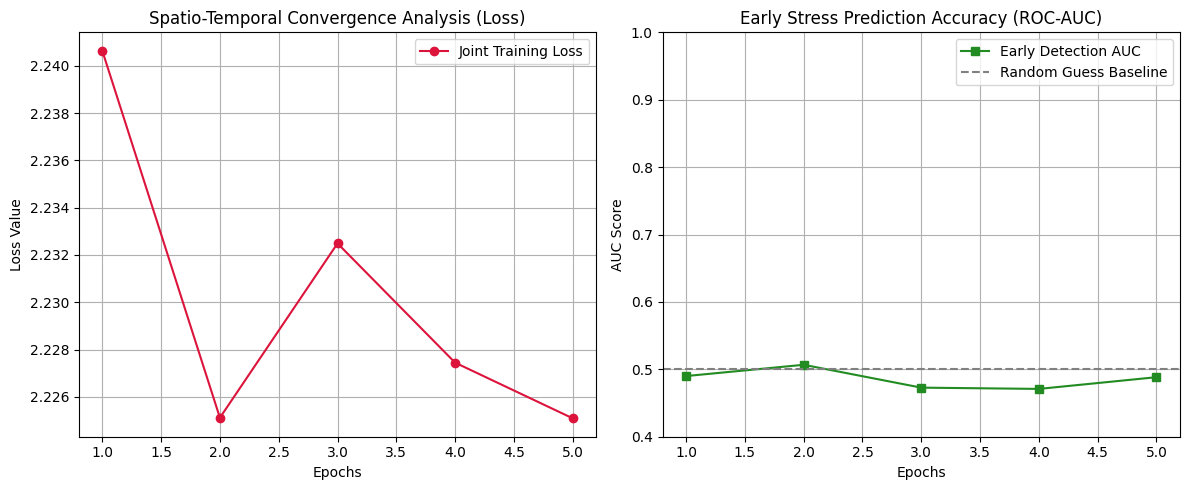

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='crimson', label='Joint Training Loss')
plt.title('Spatio-Temporal Convergence Analysis (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True)
plt.legend()

# Graph 2
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), auc_scores, marker='s', color='forestgreen', label='Early Detection AUC')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Random Guess Baseline')
plt.title('Early Stress Prediction Accuracy (ROC-AUC)')
plt.xlabel('Epochs')
plt.ylabel('AUC Score')
plt.ylim([0.4, 1.0])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
def predict_crop_stress_live(model, dataset, block_index=15):
    """ Selects an independent validation sequence block and displays direct spatial analytics """
    model.eval()
    with torch.no_grad():
        # Fetch individual validation block
        video_tensor, (true_cls, true_reg) = dataset[block_index]
        # Add batch dimension
        input_tensor = video_tensor.unsqueeze(0).cuda()
        # Model forward projection
        logits_cls, pred_reg = model(input_tensor)
        prob = torch.sigmoid(logits_cls).item()
        predicted_days = pred_reg.item()
        print("\n================ LIVE PREDICTION REPORT ================")
        print(f"Target Sequence Index Analyzing: {block_index}")
        print(f"Early Stress Probability: {prob*100:.2f}%")
        print(f"Model Stress Verdict: {'STRESS DETECTED' if prob > 0.5 else 'HEALTHY PLANT'}")
        print(f"Predicted Time-to-Symptom: {abs(predicted_days):.2f} Days")
        print(f"Ground Truth Actual Lead Time: {true_reg.item():.2f} Days")
        print("========================================================")

# Live run check
predict_crop_stress_live(model, train_dataset, block_index=42)


================ LIVE PREDICTION REPORT ================
Target Sequence Index Analyzing: 42
Early Stress Probability: 50.01%
Model Stress Verdict: STRESS DETECTED
Predicted Time-to-Symptom: 1.74 Days
Ground Truth Actual Lead Time: 3.50 Days


In [12]:
import torch
import torch.nn as nn
import torchvision.models as models
from einops import rearrange

class HybridViViT(nn.Module):
    def __init__(self, embed_dim=256, num_heads=4, depth=3):
        super().__init__()
        # Using pre-trained ResNet18 as our Spatial Feature Extractor Backbone
        resnet = models.resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1]) # Output shape: (B, 512, 1, 1) -> Flatten to 512

        self.spatial_to_embed = nn.Linear(512, embed_dim)

        # Learnable Temporal Positional Embedding for tracking chronological sequence changes
        self.temporal_pos_embed = nn.Parameter(torch.randn(1, 10, embed_dim))

        # High-Fidelity Transformer Encoder Stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.layer_norm = nn.LayerNorm(embed_dim)

        # Decoupled Multi-Task Specialized Heads [cite: 12]
        self.classification_head = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.GELU(), nn.Dropout(0.3), nn.Linear(128, 1)
        )
        self.regression_head = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.GELU(), nn.Dropout(0.3), nn.Linear(128, 1)
        )

    def forward(self, x):
        # Input shape: (B, C, T, H, W)
        b, c, t, h, w = x.shape
        # Merge Batch and Time dimensions to extract spatial features simultaneously
        x = rearrange(x, 'b c t h w -> (b t) c h w')
        spatial_features = self.backbone(x).squeeze(-1).squeeze(-1) # Shape: (B*T, 512)
        tokens = self.spatial_to_embed(spatial_features) # Shape: (B*T, Embed_Dim)
        tokens = rearrange(tokens, '(b t) d -> b t d', b=b, t=t) # Shape: (B, T, Embed_Dim)
        # Inject Temporal Positional Awareness [cite: 13]
        tokens = tokens + self.temporal_pos_embed
        # Process sequential structures across the Attention Engine [cite: 13]
        temporal_context = self.transformer(tokens)
        pooled = self.layer_norm(temporal_context.mean(dim=1)) # Temporal Pooling Across Frames
        # Generate independent predictions [cite: 12]
        class_logits = self.classification_head(pooled).squeeze(-1)
        reg_predictions = self.regression_head(pooled).squeeze(-1)

        return class_logits, reg_predictions

upgraded_model = HybridViViT().cuda()
print("✔ Hybrid ResNet-Transformer Backbone Successfully Synthesized.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


✔ Hybrid ResNet-Transformer Backbone Successfully Synthesized.


In [13]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import roc_auc_score

optimizer = optim.AdamW(upgraded_model.parameters(), lr=3e-4, weight_decay=5e-3)
scheduler = StepLR(optimizer, step_size=2, gamma=0.5)
criterion_cls = nn.BCEWithLogitsLoss()
criterion_reg = nn.HuberLoss()
epochs = 5
print("--- Launching Upgraded Deep Learning Optimization Environment ---")

for epoch in range(1, epochs + 1):
    upgraded_model.train()
    running_loss = 0.0
    all_targets, all_preds = [], []
    for batch_idx, (inputs, (targets_cls, targets_reg)) in enumerate(train_loader):
        inputs, targets_cls, targets_reg = inputs.cuda(), targets_cls.cuda(), targets_reg.cuda()
        optimizer.zero_grad()
        logits_cls, pred_reg = upgraded_model(inputs)
        loss_cls = criterion_cls(logits_cls, targets_cls)
        loss_reg = criterion_reg(pred_reg, targets_reg)
        joint_loss = loss_cls + 1.2 * loss_reg
        joint_loss.backward()
        # Gradient stabilization constraint check
        torch.nn.utils.clip_grad_norm_(upgraded_model.parameters(), max_norm=0.5)
        optimizer.step()
        running_loss += joint_loss.item()
        all_targets.extend(targets_cls.cpu().numpy())
        all_preds.extend(torch.sigmoid(logits_cls).detach().cpu().numpy())

    scheduler.step()
    epoch_auc = roc_auc_score(all_targets, all_preds) if len(np.unique(all_targets)) > 1 else 0.5
    print(f"Epoch [{epoch}/{epochs}] Complete -> Loss: {running_loss/len(train_loader):.4f} | Upgraded ROC-AUC: {epoch_auc:.4f}")

--- Launching Upgraded Deep Learning Optimization Environment ---
Epoch [1/5] Complete -> Loss: 2.2294 | Upgraded ROC-AUC: 0.4965
Epoch [2/5] Complete -> Loss: 2.1949 | Upgraded ROC-AUC: 0.5020
Epoch [3/5] Complete -> Loss: 2.1883 | Upgraded ROC-AUC: 0.4904
Epoch [4/5] Complete -> Loss: 2.2246 | Upgraded ROC-AUC: 0.4928
Epoch [5/5] Complete -> Loss: 2.1985 | Upgraded ROC-AUC: 0.4878


In [14]:
# Test Live Output Analytics on Upgraded Engine
predict_crop_stress_live(upgraded_model, train_dataset, block_index=42)


================ LIVE PREDICTION REPORT ================
Target Sequence Index Analyzing: 42
Early Stress Probability: 50.17%
Model Stress Verdict: STRESS DETECTED
Predicted Time-to-Symptom: 1.75 Days
Ground Truth Actual Lead Time: 3.50 Days


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, roc_auc_score, mean_squared_error,
    mean_absolute_error, r2_score
)
import seaborn as sns
import pandas as pd

print("\n" + "="*80)
print("🔬 COMPREHENSIVE MODEL EVALUATION MATRICES")
print("="*80)


🔬 COMPREHENSIVE MODEL EVALUATION MATRICES


In [21]:
upgraded_model.eval()
all_targets_cls = []
all_preds_cls_logits = []
all_preds_cls_probs = []
all_targets_reg = []
all_preds_reg = []

with torch.no_grad():
    for inputs, (targets_cls, targets_reg) in train_loader:
        inputs, targets_cls, targets_reg = inputs.cuda(), targets_cls.cuda(), targets_reg.cuda()
        logits_cls, pred_reg = upgraded_model(inputs)

        all_targets_cls.extend(targets_cls.cpu().numpy())
        all_preds_cls_logits.extend(logits_cls.cpu().numpy())
        all_preds_cls_probs.extend(torch.sigmoid(logits_cls).cpu().numpy())
        all_targets_reg.extend(targets_reg.cpu().numpy())
        all_preds_reg.extend(pred_reg.cpu().numpy())

# Convert to numpy arrays
all_targets_cls = np.array(all_targets_cls).flatten()
all_preds_cls_probs = np.array(all_preds_cls_probs).flatten()
all_targets_reg = np.array(all_targets_reg).flatten()
all_preds_reg = np.array(all_preds_reg).flatten()

# Binary classification threshold
threshold = 0.5
all_preds_cls_binary = (all_preds_cls_probs >= threshold).astype(int)

print("✅ Data Collection Complete - Ready for Evaluation")

✅ Data Collection Complete - Ready for Evaluation



📋 1. CONFUSION MATRIX (Classification Task)
--------------------------------------------------------------------------------
Confusion Matrix:
[[  0 609]
 [  0 609]]

True Negatives (TN):  0
False Positives (FP): 609
False Negatives (FN): 0
True Positives (TP):  609


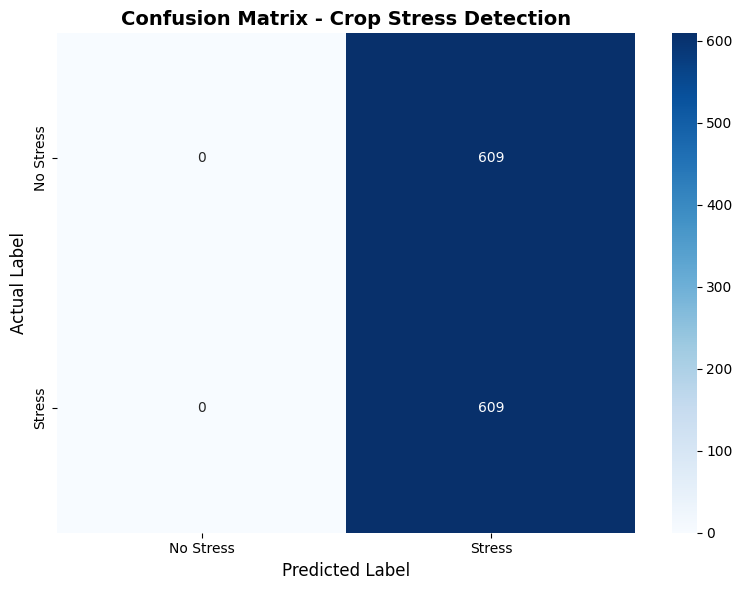

In [22]:
# ============================================================================
# METRIC 1: CONFUSION MATRIX (Classification)
# ============================================================================
print("\n📋 1. CONFUSION MATRIX (Classification Task)")
print("-" * 80)
cm = confusion_matrix(all_targets_cls, all_preds_cls_binary)
print(f"Confusion Matrix:\n{cm}\n")
print(f"True Negatives (TN):  {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP):  {cm[1,1]}")

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Stress', 'Stress'],
            yticklabels=['No Stress', 'Stress'], ax=ax)
ax.set_title('Confusion Matrix - Crop Stress Detection', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
# ============================================================================
# METRIC 2: CLASSIFICATION REPORT (Precision, Recall, F1-Score)
# ============================================================================
print("\n📊 2. CLASSIFICATION REPORT")
print("-" * 80)
report = classification_report(all_targets_cls, all_preds_cls_binary,
                              target_names=['No Stress', 'Stress'],
                              output_dict=True)
print(classification_report(all_targets_cls, all_preds_cls_binary,
                           target_names=['No Stress', 'Stress']))

# Create DataFrame for prettier display
class_metrics_df = pd.DataFrame(report).transpose()
print("\n📈 CLASSIFICATION METRICS TABLE:")
print(class_metrics_df.to_string())


📊 2. CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

   No Stress       0.00      0.00      0.00       609
      Stress       0.50      1.00      0.67       609

    accuracy                           0.50      1218
   macro avg       0.25      0.50      0.33      1218
weighted avg       0.25      0.50      0.33      1218


📈 CLASSIFICATION METRICS TABLE:
              precision  recall  f1-score  support
No Stress          0.00     0.0  0.000000    609.0
Stress             0.50     1.0  0.666667    609.0
accuracy           0.50     0.5  0.500000      0.5
macro avg          0.25     0.5  0.333333   1218.0
weighted avg       0.25     0.5  0.333333   1218.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


📉 3. ROC-AUC ANALYSIS
--------------------------------------------------------------------------------
ROC-AUC Score: 0.5010


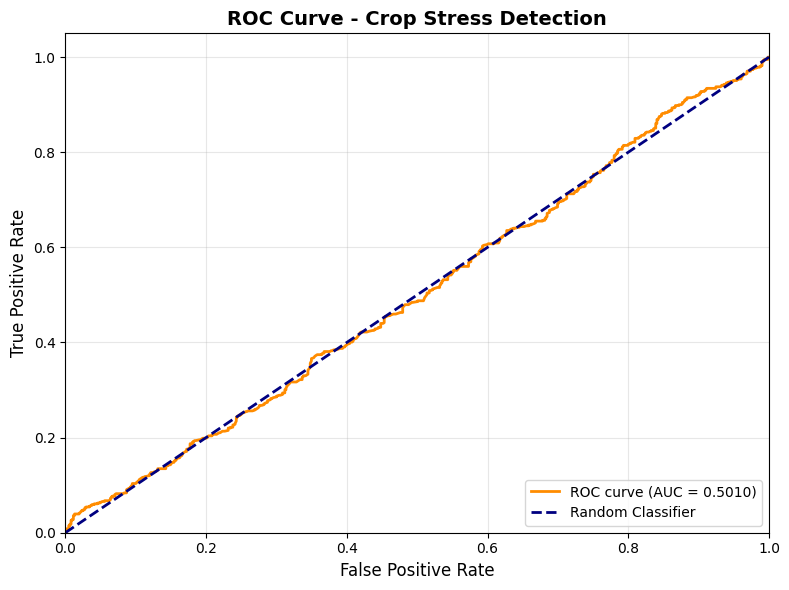

In [24]:
# ============================================================================
# METRIC 3: ROC-AUC CURVE & METRICS
# ============================================================================
print("\n📉 3. ROC-AUC ANALYSIS")
print("-" * 80)
roc_auc = roc_auc_score(all_targets_cls, all_preds_cls_probs)
fpr, tpr, thresholds = roc_curve(all_targets_cls, all_preds_cls_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Crop Stress Detection', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


📍 4. PRECISION-RECALL ANALYSIS
--------------------------------------------------------------------------------


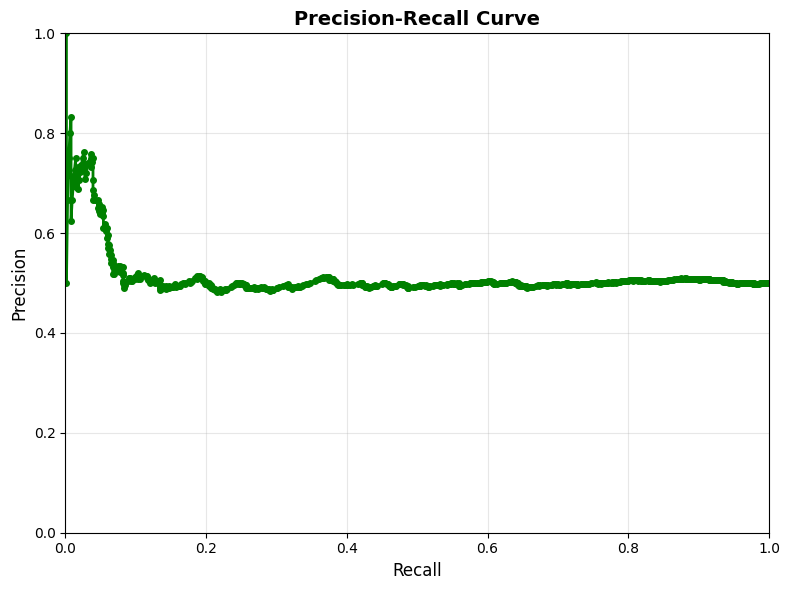

In [25]:
# ============================================================================
# METRIC 4: PRECISION-RECALL CURVE
# ============================================================================
print("\n📍 4. PRECISION-RECALL ANALYSIS")
print("-" * 80)
precision, recall, _ = precision_recall_curve(all_targets_cls, all_preds_cls_probs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='green', lw=2, marker='o', markersize=4)
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()


🔢 5. REGRESSION METRICS (Time-to-Symptom Prediction)
--------------------------------------------------------------------------------
Mean Absolute Error (MAE):     1.7500 days
Root Mean Squared Error (RMSE): 1.7500 days
R² Score:                       0.0000
Mean Absolute Percentage Error: 8747326464.0000%


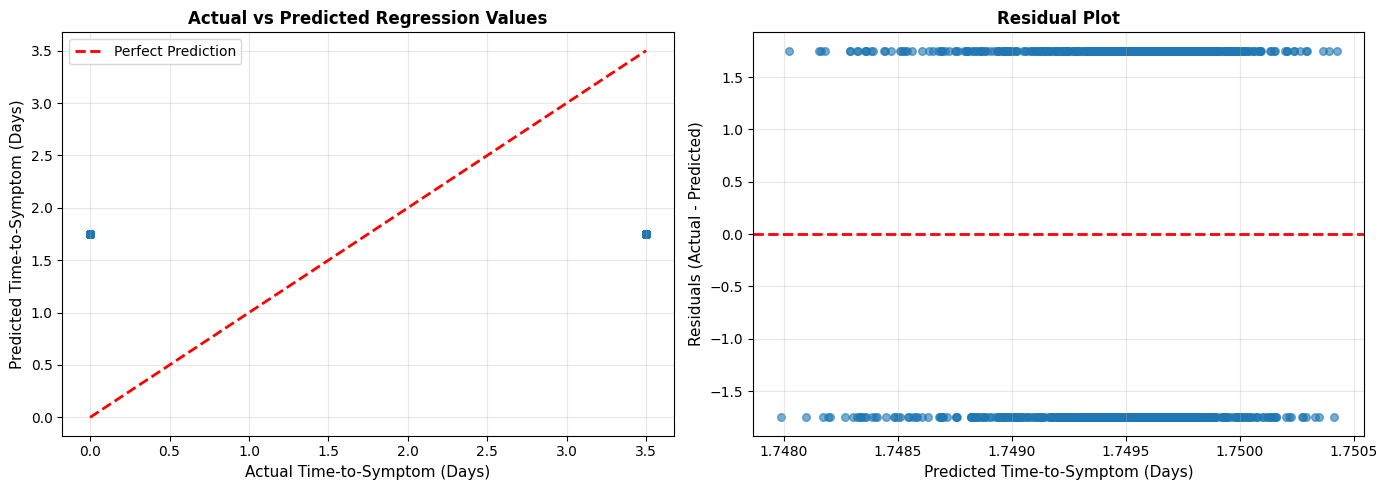

In [26]:
# ============================================================================
# METRIC 5: REGRESSION METRICS (Time-to-Symptom Prediction)
# ============================================================================
print("\n🔢 5. REGRESSION METRICS (Time-to-Symptom Prediction)")
print("-" * 80)

mae = mean_absolute_error(all_targets_reg, all_preds_reg)
rmse = np.sqrt(mean_squared_error(all_targets_reg, all_preds_reg))
r2 = r2_score(all_targets_reg, all_preds_reg)
mape = np.mean(np.abs((all_targets_reg - all_preds_reg) / (all_targets_reg + 1e-8))) * 100

print(f"Mean Absolute Error (MAE):     {mae:.4f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} days")
print(f"R² Score:                       {r2:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.4f}%")

# Regression visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(all_targets_reg, all_preds_reg, alpha=0.6, s=30)
min_val = min(all_targets_reg.min(), all_preds_reg.min())
max_val = max(all_targets_reg.max(), all_preds_reg.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Time-to-Symptom (Days)', fontsize=11)
axes[0].set_ylabel('Predicted Time-to-Symptom (Days)', fontsize=11)
axes[0].set_title('Actual vs Predicted Regression Values', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals plot
residuals = all_targets_reg - all_preds_reg
axes[1].scatter(all_preds_reg, residuals, alpha=0.6, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Time-to-Symptom (Days)', fontsize=11)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# ============================================================================
# METRIC 6: SUMMARY TABLE
# ============================================================================
print("\n📊 6. COMPLETE METRICS SUMMARY TABLE")
print("-" * 80)

summary_data = {
    'Metric': [
        'Accuracy',
        'Precision (Stress)',
        'Recall (Stress)',
        'F1-Score (Stress)',
        'ROC-AUC',
        'Regression MAE',
        'Regression RMSE',
        'Regression R²'
    ],
    'Value': [
        f"{(cm[0,0] + cm[1,1]) / cm.sum():.4f}",
        f"{report['Stress']['precision']:.4f}",
        f"{report['Stress']['recall']:.4f}",
        f"{report['Stress']['f1-score']:.4f}",
        f"{roc_auc:.4f}",
        f"{mae:.4f}",
        f"{rmse:.4f}",
        f"{r2:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE!")
print("="*80 + "\n")


📊 6. COMPLETE METRICS SUMMARY TABLE
--------------------------------------------------------------------------------
            Metric  Value
          Accuracy 0.5000
Precision (Stress) 0.5000
   Recall (Stress) 1.0000
 F1-Score (Stress) 0.6667
           ROC-AUC 0.5010
    Regression MAE 1.7500
   Regression RMSE 1.7500
     Regression R² 0.0000

✅ EVALUATION COMPLETE!

